In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [18]:
df = pd.read_csv("D:/Projects/corporate-bond-default/data/raw/dataset_csv.csv", sep =r"\s+")

In [19]:
df.shape

(4211, 33)

In [20]:
df.head()

,obs_id,class,default,x1,x2,x3,x4,x5,x6,x7,...,x21,x22,x23,x24,x25,x26,time,year,testing_set,training_set
0,0,1406,0,0.548690,0.378213,0.516406,1.608842,0.602419,0.065173,0.558509,...,0.537593,0.001444,0.382384,0.033177,1.000000,0,1,2007,1,0
1,1,1406,0,0.547813,0.378383,0.516522,1.699176,0.601911,0.062662,0.557950,...,0.572315,0.001311,0.380498,0.028798,1.000000,0,2,2008,1,0
2,2,1406,0,0.549332,0.378818,0.514555,1.734131,0.603207,0.063617,0.559306,...,0.583454,0.001697,0.381134,0.030690,1.000000,0,3,2009,1,0
3,3,1406,0,0.552237,0.379319,0.512808,1.852136,0.605443,0.078868,0.565012,...,0.583256,0.001229,0.368001,0.062207,0.903143,0,4,2010,1,0
4,4,1406,0,0.550137,0.379200,0.515377,1.750650,0.603519,0.084289,0.560092,...,0.569079,0.001034,0.368143,0.073117,0.922740,0,5,2011,1,0


In [21]:
df.tail()

,obs_id,class,default,x1,x2,x3,x4,x5,x6,x7,...,x21,x22,x23,x24,x25,x26,time,year,testing_set,training_set
4206,4206,54984,0,0.542723,0.373749,0.550308,0.392159,0.590448,0.069310,0.550825,...,0.597256,2.138156,1.115053,0.038556,0.943278,0,1,2015,1,0
4207,4207,54984,0,0.648290,0.384537,0.517096,0.406113,0.625153,0.078262,0.558577,...,0.512141,0.184817,0.365182,0.017708,0.965658,0,2,2016,1,0
4208,4208,54984,0,0.620559,0.393311,0.512871,0.408022,0.631175,0.085568,0.561392,...,0.584074,0.132024,0.365182,0.028232,0.945022,0,3,2017,1,0
4209,4209,55222,0,0.542723,0.403193,0.494717,0.381386,0.568214,0.110941,0.537031,...,0.567425,0.366094,0.375811,0.138021,1.000000,0,1,2015,0,1
4210,4210,55222,0,0.485341,0.388860,0.485143,0.383611,0.547295,0.098208,0.525303,...,0.543300,0.509464,0.376287,0.089273,1.000000,0,2,2016,0,1


In [22]:
df.columns

Index(['obs_id', 'class', 'default', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7',
       'x8', 'x9', 'x10', 'x11', 'x12', 'x13', 'x14', 'x15', 'x16', 'x17',
       'x18', 'x19', 'x20', 'x21', 'x22', 'x23', 'x24', 'x25', 'x26', 'time',
       'year', 'testing_set', 'training_set'],
      dtype='object')

In [23]:
df.dtypes

obs_id            int64
class             int64
default           int64
x1              float64
x2              float64
x3              float64
x4              float64
x5              float64
x6              float64
x7              float64
x8              float64
x9              float64
x10             float64
x11             float64
x12             float64
x13             float64
x14             float64
x15             float64
x16             float64
x17             float64
x18             float64
x19             float64
x20             float64
x21             float64
x22             float64
x23             float64
x24             float64
x25             float64
x26               int64
time              int64
year              int64
testing_set       int64
training_set      int64
dtype: object

In [24]:
df.describe()

,obs_id,class,default,x1,x2,x3,x4,x5,x6,x7,...,x21,x22,x23,x24,x25,x26,time,year,testing_set,training_set
count,4211.000000,4211.000000,4211.000000,4211.000000,4211.000000,4211.000000,4211.000000,4211.000000,4211.000000,4211.000000,...,4211.000000,4211.000000,4211.000000,4211.000000,4211.000000,4211.000000,4211.000000,4211.000000,4211.000000,4211.000000
mean,2105.000000,33311.420328,0.039896,0.539776,0.413190,0.403101,0.419014,0.577398,0.180425,0.452534,...,0.561975,0.053268,0.436640,0.096531,0.875320,0.013536,4.607932,2012.684161,0.296842,0.703158
std,1215.755321,8824.278669,0.195737,0.108803,0.291308,7.891078,0.120112,0.157482,2.598298,5.550342,...,0.265998,0.143560,0.871935,0.288812,1.542352,0.115568,2.645558,2.690439,0.456920,0.456920
min,0.000000,1406.000000,0.000000,-0.762719,-3.121067,-509.496063,-1.478051,-4.937693,0.000000,-359.254913,...,-11.481653,-0.000493,-2.136715,0.000000,-98.204216,0.000000,1.000000,2007.000000,0.000000,0.000000
25%,1052.500000,27746.000000,0.000000,0.534412,0.377899,0.494682,0.382754,0.579986,0.073599,0.540543,...,0.547802,0.000042,0.365896,0.023076,0.866353,0.000000,2.000000,2011.000000,0.000000,0.000000
50%,2105.000000,34471.000000,0.000000,0.542723,0.382454,0.507672,0.395277,0.600857,0.086827,0.553389,...,0.587224,0.001835,0.377339,0.045168,0.958493,0.000000,4.000000,2013.000000,0.000000,1.000000
75%,3157.500000,38987.000000,0.000000,0.567753,0.396540,0.526727,0.429524,0.614113,0.124755,0.561683,...,0.597256,0.032784,0.416180,0.087511,1.000000,0.000000,7.000000,2015.000000,1.000000,1.000000
max,4210.000000,55222.000000,1.000000,4.381475,14.845502,43.535725,1.950204,1.818078,167.955734,5.999214,...,10.128810,2.138156,47.230267,10.656795,1.000000,1.000000,11.000000,2017.000000,1.000000,1.000000


In [25]:
df.describe(include="all")


,obs_id,class,default,x1,x2,x3,x4,x5,x6,x7,...,x21,x22,x23,x24,x25,x26,time,year,testing_set,training_set
count,4211.000000,4211.000000,4211.000000,4211.000000,4211.000000,4211.000000,4211.000000,4211.000000,4211.000000,4211.000000,...,4211.000000,4211.000000,4211.000000,4211.000000,4211.000000,4211.000000,4211.000000,4211.000000,4211.000000,4211.000000
mean,2105.000000,33311.420328,0.039896,0.539776,0.413190,0.403101,0.419014,0.577398,0.180425,0.452534,...,0.561975,0.053268,0.436640,0.096531,0.875320,0.013536,4.607932,2012.684161,0.296842,0.703158
std,1215.755321,8824.278669,0.195737,0.108803,0.291308,7.891078,0.120112,0.157482,2.598298,5.550342,...,0.265998,0.143560,0.871935,0.288812,1.542352,0.115568,2.645558,2.690439,0.456920,0.456920
min,0.000000,1406.000000,0.000000,-0.762719,-3.121067,-509.496063,-1.478051,-4.937693,0.000000,-359.254913,...,-11.481653,-0.000493,-2.136715,0.000000,-98.204216,0.000000,1.000000,2007.000000,0.000000,0.000000
25%,1052.500000,27746.000000,0.000000,0.534412,0.377899,0.494682,0.382754,0.579986,0.073599,0.540543,...,0.547802,0.000042,0.365896,0.023076,0.866353,0.000000,2.000000,2011.000000,0.000000,0.000000
50%,2105.000000,34471.000000,0.000000,0.542723,0.382454,0.507672,0.395277,0.600857,0.086827,0.553389,...,0.587224,0.001835,0.377339,0.045168,0.958493,0.000000,4.000000,2013.000000,0.000000,1.000000
75%,3157.500000,38987.000000,0.000000,0.567753,0.396540,0.526727,0.429524,0.614113,0.124755,0.561683,...,0.597256,0.032784,0.416180,0.087511,1.000000,0.000000,7.000000,2015.000000,1.000000,1.000000
max,4210.000000,55222.000000,1.000000,4.381475,14.845502,43.535725,1.950204,1.818078,167.955734,5.999214,...,10.128810,2.138156,47.230267,10.656795,1.000000,1.000000,11.000000,2017.000000,1.000000,1.000000


In [26]:
df.isna().sum()


obs_id          0
class           0
default         0
x1              0
x2              0
x3              0
x4              0
x5              0
x6              0
x7              0
x8              0
x9              0
x10             0
x11             0
x12             0
x13             0
x14             0
x15             0
x16             0
x17             0
x18             0
x19             0
x20             0
x21             0
x22             0
x23             0
x24             0
x25             0
x26             0
time            0
year            0
testing_set     0
training_set    0
dtype: int64

In [28]:
df.nunique()



obs_id          4211
class            571
default            2
x1              3357
x2              3979
x3              4071
x4              4045
x5              4128
x6              4074
x7              4083
x8              4097
x9              4116
x10             4089
x11             3786
x12             3960
x13             3509
x14             2735
x15             2892
x16             2871
x17             3716
x18             3941
x19             3598
x20             3249
x21             3608
x22             2700
x23             3532
x24             4055
x25             2867
x26                2
time              11
year              11
testing_set        2
training_set       2
dtype: int64

In [29]:
df.columns[df.nunique() <= 1]


Index([], dtype='object')

In [30]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4211 entries, 0 to 4210
Data columns (total 33 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   obs_id        4211 non-null   int64  
 1   class         4211 non-null   int64  
 2   default       4211 non-null   int64  
 3   x1            4211 non-null   float64
 4   x2            4211 non-null   float64
 5   x3            4211 non-null   float64
 6   x4            4211 non-null   float64
 7   x5            4211 non-null   float64
 8   x6            4211 non-null   float64
 9   x7            4211 non-null   float64
 10  x8            4211 non-null   float64
 11  x9            4211 non-null   float64
 12  x10           4211 non-null   float64
 13  x11           4211 non-null   float64
 14  x12           4211 non-null   float64
 15  x13           4211 non-null   float64
 16  x14           4211 non-null   float64
 17  x15           4211 non-null   float64
 18  x16           4211 non-null 

In [31]:
(df < 0).sum()


obs_id           0
class            0
default          0
x1               3
x2               1
x3              17
x4               4
x5              16
x6               0
x7              19
x8              21
x9               0
x10             15
x11             40
x12             18
x13             14
x14             21
x15             30
x16             26
x17             11
x18             12
x19              0
x20             14
x21             12
x22              4
x23              9
x24              0
x25             12
x26              0
time             0
year             0
testing_set      0
training_set     0
dtype: int64

In [32]:
np.isinf(df.values).sum()


np.int64(0)

In [35]:
target = "default"
df[target].value_counts(normalize=True)*100


default
0    96.010449
1     3.989551
Name: proportion, dtype: float64

In [36]:
df[target].value_counts(normalize=True).min()


np.float64(0.03989551175492757)

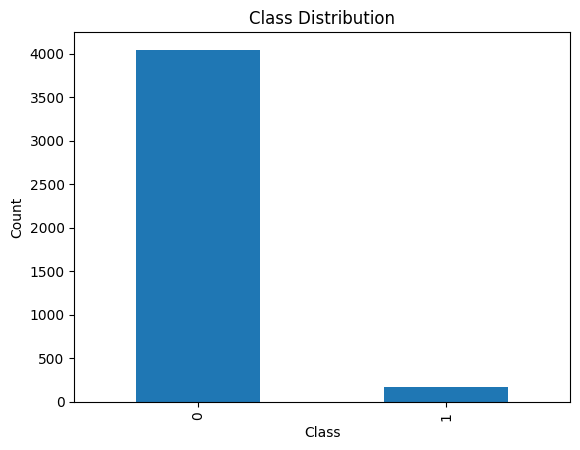

In [41]:
df[target].value_counts().plot(kind="bar")
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()

Dataset is imbalanced.

default

0  -  96.010449%

1   -  3.989551%

Accuracy is bad metric here, so other metrics like precision, recall, f1-score, etc. are better.

In [42]:
df["class"].value_counts()


class
14770    11
18914    11
22895    11
23313    11
22909    11
         ..
55222     2
25343     1
22951     1
34837     1
40324     1
Name: count, Length: 571, dtype: int64

In [43]:
df["class"].nunique()


571

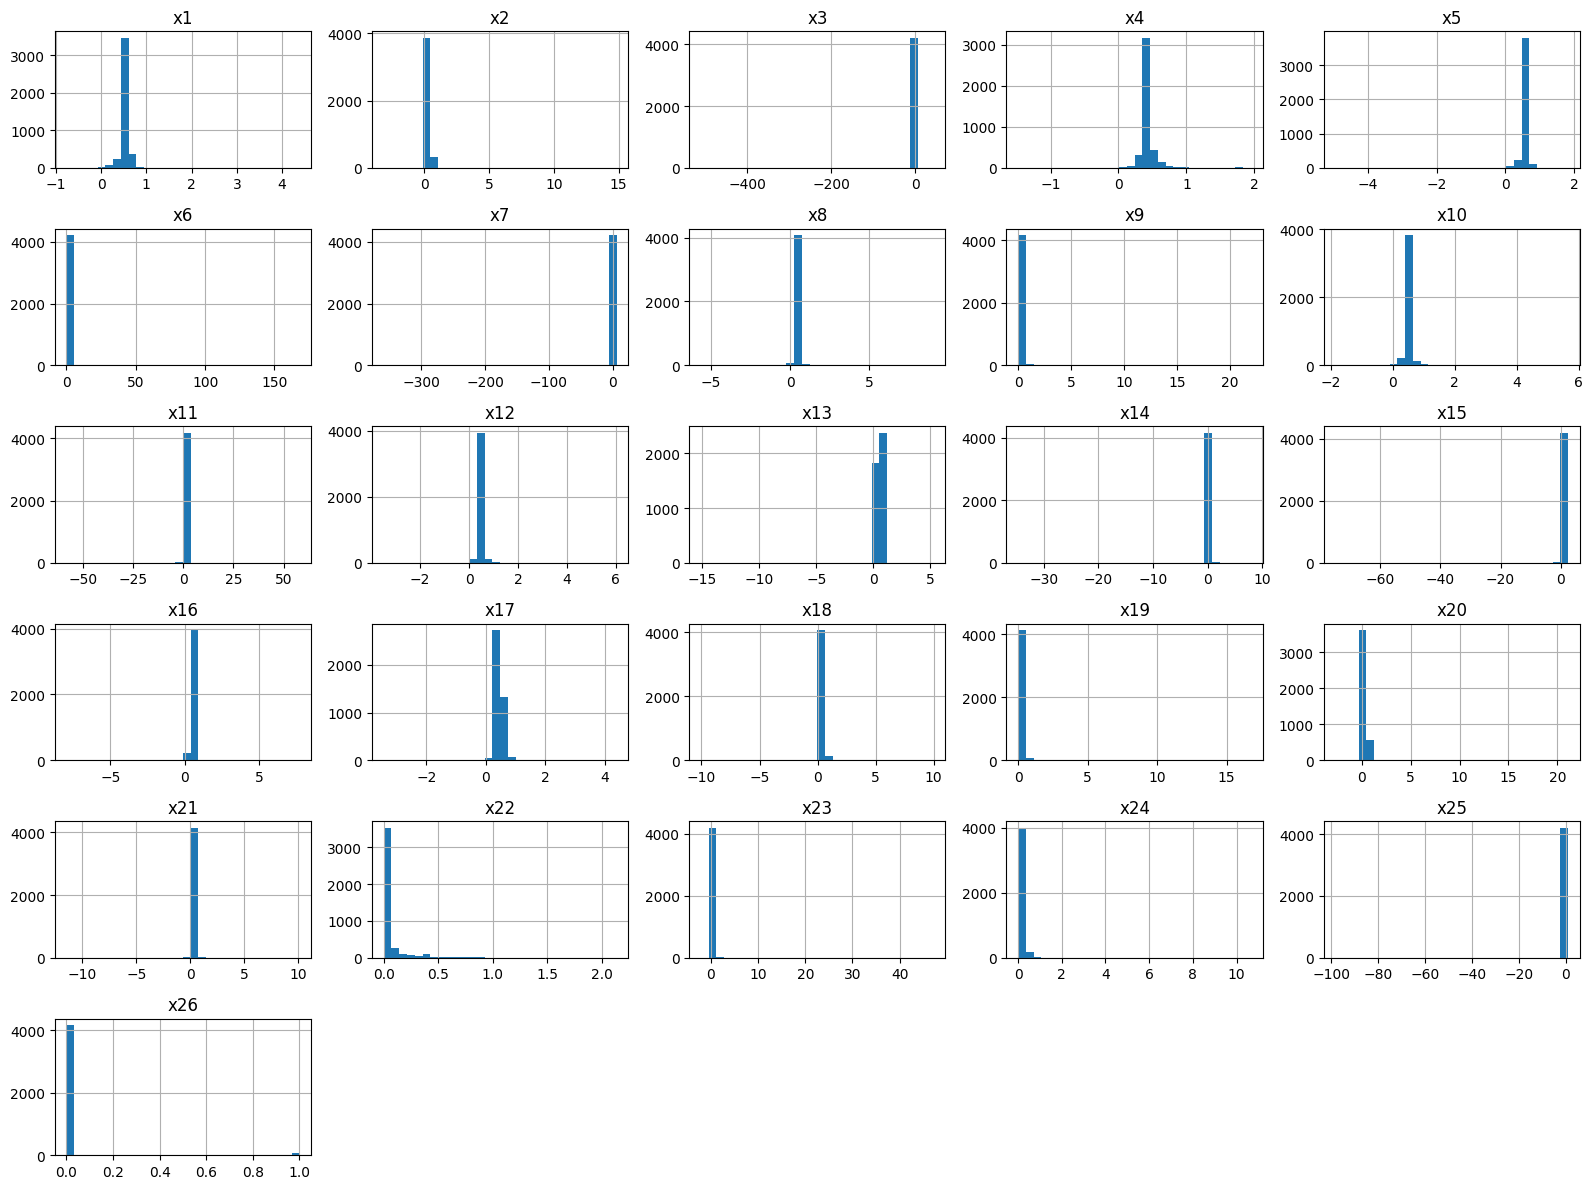

In [44]:
feature_cols = [f"x{i}" for i in range(1, 27)]
df[feature_cols].hist(bins=30, figsize=(16, 12))
plt.tight_layout()
plt.show()


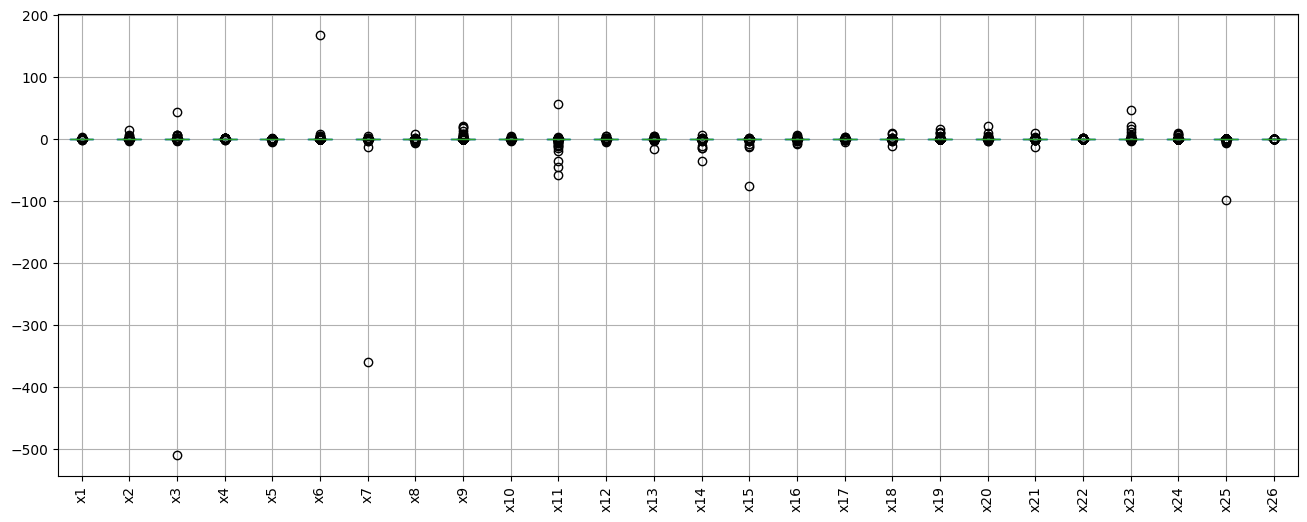

In [45]:
plt.figure(figsize=(16, 6))
df[feature_cols].boxplot(rot=90)
plt.show()


In [47]:
df["year"].value_counts().sort_index()


year
2007     96
2008    194
2009    316
2010    391
2011    469
2012    505
2013    497
2014    487
2015    477
2016    461
2017    318
Name: count, dtype: int64

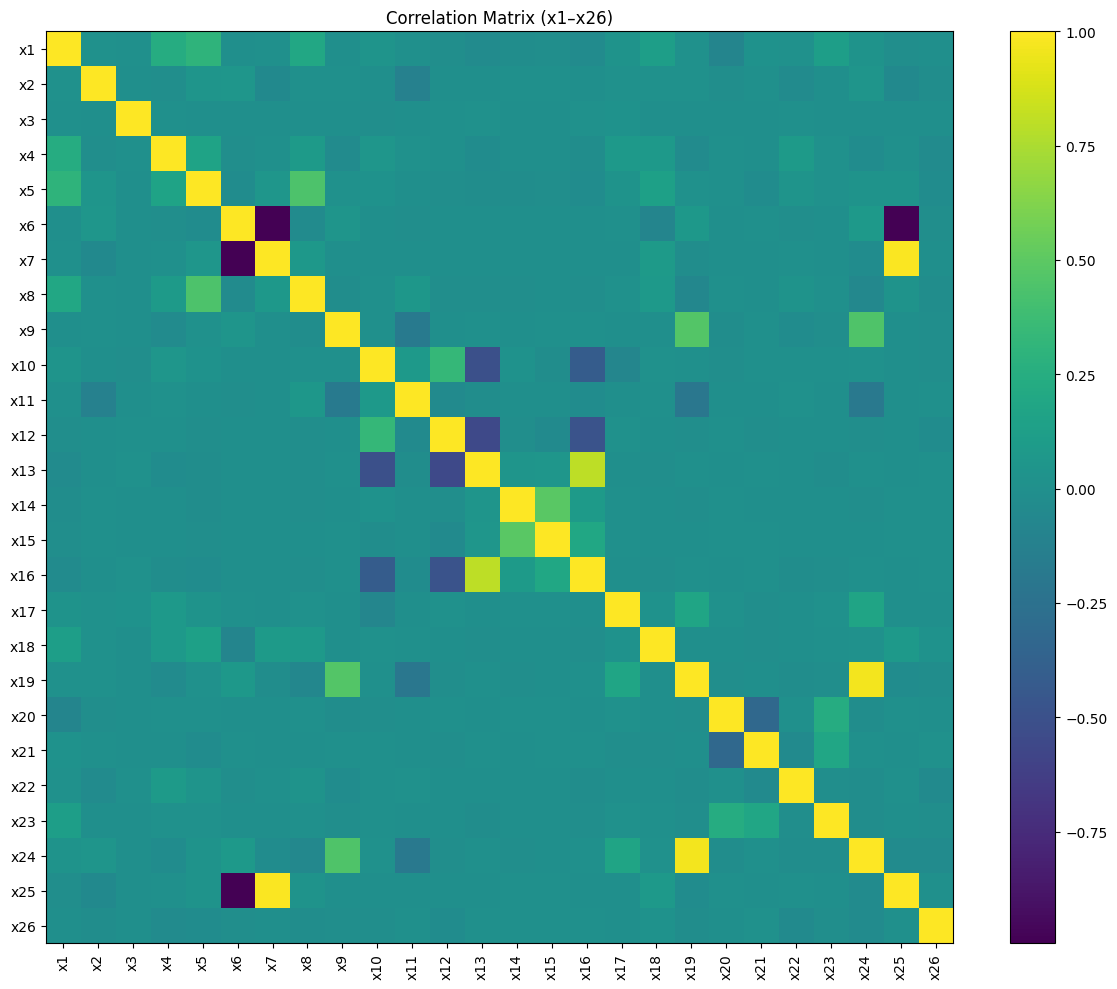

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(feature_cols)), feature_cols, rotation=90)
plt.yticks(range(len(feature_cols)), feature_cols)
plt.title("Correlation Matrix (x1–x26)")
plt.tight_layout()
plt.show()


In [50]:

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr_pairs = upper.stack().reset_index()
high_corr_pairs.columns = ["feature_1", "feature_2", "correlation"]
high_corr_pairs[high_corr_pairs["correlation"].abs() > 0.8].sort_values(by="correlation", ascending=False)


,feature_1,feature_2,correlation
152,x7,x25,0.989593
301,x19,x24,0.964510
236,x13,x16,0.801191
133,x6,x25,-0.987778
115,x6,x7,-0.994414


class column represents like company id

28 numerical features (namely x1 to x26; time and year)

training and test set columns exist for data splitting (have to be removed after splitting the data for training and testing)

no categorical features exist.

features are already min-max scaled.

target column is 'default' (0: no default, 1: default)


Dataset is imbalanced.

default

0  -  96.010449%

1   -  3.989551%

Accuracy is bad metric here, so other metrics like precision, recall, f1-score, etc. are better.

![alt text](image.png)

correlated features

The 'time' column acts as an index for the values in 'year' column. (1 - 2007, 2 - 2008, 11 - 2017)

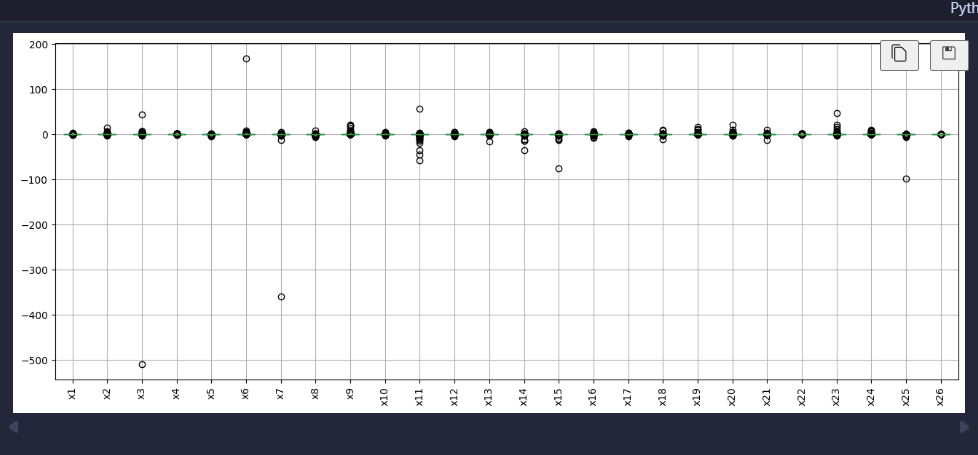

remove x7

remove x19

remove x25

